### **아키텍처 개요**

전체 아키텍처는 크게 **관리자 에이전트(Manager Agent)**와 **작업자 에이전트(Worker Agent)**로 나뉩니다. 관리자 에이전트는 사용자의 지시를 받아 전체 계획을 수립하고, 각 단계에 맞는 작업자 에이전트에게 일을 할당합니다. 작업자 에이전트는 Selenium을 사용하여 실제 웹 브라우저를 제어하며 특정 작업을 수행합니다.



---

### **에이전트별 역할 및 구성**

#### **1. 관리자 에이전트 (Manager Agent)**
-   **역할**: 전체 워크플로우를 조율하는 상위 에이전트입니다.
-   **구성 요소**:
    -   **`Planner`**: 사용자 입력(예: "케이팝데몬헌터스에 대해 검색하고 결과를 크롤링해줘")을 분석하여 전체 작업 흐름에 대한 단계별 계획을 수립합니다. 이 계획은 '검색', '이동', '크롤링'과 같이 추상적인 작업 단위로 이루어집니다.
    -   **`Router`**: 수립된 계획의 각 단계에 따라 적절한 작업자 에이전트에게 작업을 위임합니다.

#### **2. 작업자 에이전트 (Worker Agent)**
-   **역할**: 관리자 에이전트로부터 위임받은 구체적인 작업을 수행합니다. Selenium을 직접 제어하는 역할을 담당합니다.
-   **유형 및 구성 요소**:
    -   **`Search Agent`**:
        -   **목표**: 특정 키워드를 검색하고, 결과 페이지의 URL을 획득합니다.
        -   **작업**: Selenium을 사용하여 구글과 같은 검색 엔진에 접속하고, 검색창에 키워드(`케이팝데몬헌터스`)를 입력한 후 검색을 실행합니다. 검색 결과 중 가장 관련성 높은 페이지의 URL을 추출하여 관리자에게 반환합니다.
    -   **`Navigator Agent`**:
        -   **목표**: 특정 URL로 이동하여 페이지의 내용을 파싱(Parsing)합니다.
        -   **작업**: 관리자로부터 받은 URL을 사용하여 Selenium으로 페이지에 접속합니다. 페이지의 HTML 소스를 가져와서, 다음 단계인 크롤링에 필요한 특정 요소(예: 검색 결과 목록, 기사 내용)를 식별하고 정보를 전달합니다.
    -   **`Crawler Agent`**:
        -   **목표**: 특정 페이지 또는 요소에서 데이터를 추출합니다.
        -   **작업**: 관리자나 `Navigator Agent`로부터 받은 정보(페이지 소스, 추출할 요소의 CSS 선택자 등)를 바탕으로 Selenium을 통해 웹페이지의 특정 데이터(텍스트, 이미지 URL 등)를 크롤링하여 관리자에게 반환합니다.

---

### **워크플로우 시나리오**

1.  **시작**: 사용자 요청("케이팝데몬헌터스에 대해 검색하고 결과를 크롤링해줘")이 관리자 에이전트에게 전달됩니다.
2.  **계획**: 관리자 에이전트의 `Planner`가 다음과 같은 계획을 수립합니다.
    -   **_계획 1_**: "케이팝데몬헌터스" 검색
    -   **_계획 2_**: 검색 결과 페이지로 이동
    -   **_계획 3_**: 웹페이지에서 관련 정보 크롤링
3.  **실행 (단계별 위임)**:
    -   `Router`는 **_계획 1_**을 `Search Agent`에게 위임합니다.
    -   `Search Agent`는 Selenium으로 검색을 수행하고, 관련 페이지 URL(예: `https://.../kpop-demon-hunters`)을 반환합니다.
    -   `Router`는 **_계획 2_**와 URL을 `Navigator Agent`에게 위임합니다.
    -   `Navigator Agent`는 Selenium으로 해당 URL에 접속하여 페이지의 소스를 가져옵니다.
    -   `Router`는 **_계획 3_**과 페이지 소스를 `Crawler Agent`에게 위임합니다.
    -   `Crawler Agent`는 제공된 소스에서 특정 데이터를 크롤링하고 그 결과를 반환합니다.
4.  **최종 보고**: 관리자 에이전트는 각 작업자 에이전트로부터 받은 결과를 종합하여 사용자에게 최종 보고서를 작성하고 응답합니다.

In [66]:
import operator
import uuid
from typing import Annotated, Any, List, Tuple, Dict
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# runnables
from langchain_core.runnables import RunnableLambda, RunnableBranch

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

from dotenv import load_dotenv
load_dotenv()

# 웹 드라이버 초기화 (전역 변수로 관리)
# 사용자에게 브라우저 화면이 보이도록 headless 모드를 사용하지 않습니다.
driver = webdriver.Chrome()

# TypedDict 사용하여 상태 정의
class WebBrowsingState(TypedDict):
    input: Annotated[str, "User's input"]
    plan: Annotated[List[str], "Current plan"]
    past_steps: Annotated[List[Tuple[str, str]], "List of (task, result_str)"]
    response: Annotated[str, "Final response"]

# BaseModel 사용하여 런타임 데이터 검증
class Plan(BaseModel):
    steps: List[str] = Field(description="List of steps to be performed.")

# LLM 모델 정의
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

# planner_prompt
planner_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", """당신은 사용자 요청을 달성하기 위해 Selenium으로 웹 브라우저를 제어하는 구체적인 단계를 계획하는 전문 플래너입니다.
        모든 단계는 Selenium에서 실행 가능한 명령어 형식으로 작성해야 합니다.
        예시:
        - "www.google.com으로 이동합니다."
        - "'q'라는 name 속성을 가진 검색창 요소를 찾습니다."
        - "검색창에 '케이팝데몬헌터스'를 입력합니다."
        - "엔터 키를 입력합니다."
        - "검색 결과에서 제목과 요약 내용을 크롤링합니다."
        - "크롤링된 정보를 요약합니다."
        - "최종 보고서를 생성합니다."
        
        주의: 단계는 반드시 한글로 작성해야 합니다.
        
        사용자의 요청을 분석하고, 가장 효율적인 계획을 수립하세요.
        최종 단계는 항상 "최종 보고서를 생성합니다."여야 합니다.
        """),
        ("placeholder", "{messages}"),
    ]
)
planner = planner_prompt | llm.with_structured_output(Plan)


def plan_step(state: WebBrowsingState) -> Dict[str, Any]:
    """사용자 입력에 따라 Selenium 기반의 계획을 수립합니다."""
    print("▶︎ 플래너 에이전트: 실행 가능한 계획을 수립합니다.")
    plan = planner.invoke({"messages": [("user", state["input"])]})

    # 생성된 계획의 마지막 단계가 "최종 보고서 생성"이 아닌 경우 추가
    if not plan.steps or plan.steps[-1] != "최종 보고서를 생성합니다.":
        plan.steps.append("최종 보고서를 생성합니다.")

    print("\n--- 수립된 계획 ---")
    for idx, step in enumerate(plan.steps, 1):
        print(f"{idx}. {step}")
    print("-------------------\n")

    return {"plan": plan.steps}


# === Selenium 제어 도구들 ===
@tool
def navigate_to_url(url: str) -> str:
    """주어진 URL로 이동합니다."""
    print(f"URL 이동: {url}")
    try:
        driver.get(url)
        return f"{url}로 성공적으로 이동했습니다."
    except Exception as e:
        return f"URL 이동 실패: {e}"


@tool
def find_and_type_text(selector: str, text: str) -> str:
    """주어진 CSS 선택자로 요소를 찾아 텍스트를 입력합니다."""
    print(f"텍스트 입력: '{selector}'에 '{text}' 입력")
    try:
        element = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, selector))
        )
        element.send_keys(text)
        return f"요소 '{selector}'에 텍스트 '{text}'를 성공적으로 입력했습니다."
    except Exception as e:
        return f"텍스트 입력 실패: {e}"


@tool
def press_key(key: str) -> str:
    """활성화된 요소에 주어진 키를 누릅니다."""
    print(f"키 입력: {key}")
    try:
        if key.upper() == "ENTER":
            driver.switch_to.active_element.send_keys(Keys.ENTER)
        else:
            driver.switch_to.active_element.send_keys(key)
        return f"키 '{key}'를 성공적으로 눌렀습니다."
    except Exception as e:
        return f"키 입력 실패: {e}"


@tool
def scrape_data(selector: str) -> str:
    """주어진 CSS 선택자로 데이터를 크롤링합니다."""
    print(f"데이터 크롤링: {selector}")
    try:
        elements = driver.find_elements(By.CSS_SELECTOR, selector)
        data = "\n".join([el.text for el in elements if el.text])
        return f"웹페이지에서 정보를 크롤링했습니다.\n크롤링된 내용:\n{data}"
    except Exception as e:
        return f"데이터 크롤링 실패: {e}"


# Agent가 사용할 도구 목록
tools = [navigate_to_url, find_and_type_text, press_key, scrape_data]


# Helper: 도구 이름 → callable 맵 생성 (유연하게 처리)
def build_tool_registry(tool_list: List[Any]) -> Dict[str, Any]:
    registry = {}
    for t in tool_list:
        # try common attribute names for tool name
        name = getattr(t, "name", None) or getattr(t, "__name__", None) or getattr(t, "tool_name", None)
        if not name:
            continue
        registry[name] = t
    return registry


TOOL_REGISTRY = build_tool_registry(tools)


# Agent 프롬프트: 주어진 태스크에 가장 적합한 도구를 선택하도록 지시
tool_agent_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", """당신은 주어진 작업을 수행하기 위해 도구를 사용하는 에이전트입니다.
        사용 가능한 도구는 {tool_names}입니다.
        - navigate_to_url: 주어진 URL로 이동합니다.
        - find_and_type_text: 주어진 CSS 선택자를 사용하여 요소를 찾고 텍스트를 입력합니다.
        - press_key: 활성화된 요소에 키를 누릅니다 (예: 'ENTER').
        - scrape_data: 주어진 CSS 선택자를 사용하여 데이터를 크롤링합니다.
        
        계획의 한 단계인 "{task}"를 분석하여 가장 적합한 도구를 사용하세요.
        """),
        ("placeholder", "{messages}"),
    ]
).partial(tool_names=", ".join(list(TOOL_REGISTRY.keys())))

# tool_agent 정의 (LLM과 프롬프트, 도구 바인딩)
# bind_tools를 사용하면 LLM이 tool call을 생성할 수 있습니다.
tool_agent = tool_agent_prompt | llm.bind_tools(tools)


# === tool_agent 출력 정규화 & 실행 로직 ===
def normalize_tool_agent_output(x: Any) -> Dict[str, Any]:
    """
    tool_agent의 출력을 항상 dict 형태로 정규화합니다.
    가능한 입력:
      - 객체(예: AIMessage with .tool_calls)
      - dict (이미 직렬화된 tool_calls 포함)
    결과 예:
      {"tool_calls": [ ... ]}
    """
    if x is None:
        return {}
    # 객체형태에서 .tool_calls가 있는 경우 (LangChain 도구 호출 객체)
    if hasattr(x, "tool_calls"):
        return {"tool_calls": getattr(x, "tool_calls") or []}
    # 이미 dict 형태면 그대로 반환
    if isinstance(x, dict):
        return x
    # fallback: 문자열 등일 수 있으므로 빈 dict 반환
    return {}


def execute_tool_call_entry(tool_call_entry: Any) -> Any:
    """
    tool_call_entry는 다음 중 하나일 수 있음:
     - 객체 형태의 ToolInvocation (has .invoke)
     - dict 형태: {"name": "...", "args": {...}} 또는 {"tool": "...", "arguments": {...}}
    이 함수를 통해 실제 도구를 찾아 실행하고 결과를 반환합니다.
    """
    try:
        # 1) 객체형: .invoke() 가능하면 invoke 사용
        if hasattr(tool_call_entry, "invoke"):
            return tool_call_entry.invoke()

        # 2) dict 형태 처리
        if isinstance(tool_call_entry, dict):
            # 가능한 키 이름들을 유연하게 찾음
            name = tool_call_entry.get("name") or tool_call_entry.get("tool") or tool_call_entry.get("tool_name")
            args = tool_call_entry.get("args") or tool_call_entry.get("arguments") or {}
            if not name:
                return {"error": "tool name not provided in tool_call entry", "entry": tool_call_entry}

            # 도구 레지스트리에서 찾기
            tool_callable = TOOL_REGISTRY.get(name)
            if tool_callable is None:
                # 이름이 함수 이름(언더스코어/대소문자 차이 등)일 수 있으므로 일부 정규화 시도
                if name in TOOL_REGISTRY:
                    tool_callable = TOOL_REGISTRY[name]
                else:
                    # 실패: 등록되지 않은 도구
                    return {"error": f"tool '{name}' not found in registry", "entry": tool_call_entry}

            # tool_callable이 객체(도구 래퍼)이고 .invoke() 있다면 invoke 사용
            if hasattr(tool_callable, "invoke"):
                return tool_callable.invoke(**(args or {}))
            else:
                # 일반 함수라면 직접 호출
                return tool_callable(**(args or {}))

        # 기타 타입(문자열 등)은 그대로 반환
        return {"unhandled_tool_call_type": str(tool_call_entry)}
    except Exception as e:
        return {"error": f"exception during tool execution: {e}", "entry": str(tool_call_entry)}


def invoke_first_tool_from_agent_output(agent_output: Dict[str, Any]) -> Dict[str, Any]:
    """
    agent_output은 normalize_tool_agent_output()로 정규화된 dict여야 함.
    첫 번째 tool_call을 찾아 실행하고 결과를 dict로 반환.
    """
    if not agent_output:
        return {}
    tool_calls = agent_output.get("tool_calls") or []
    if not tool_calls:
        return {}

    # 실행할 첫 도구
    first_call = tool_calls[0]
    result = execute_tool_call_entry(first_call)
    # 항상 dict로 반환하여 downstream에서 일관되게 처리
    return {"tool_result": result, "tool_call": first_call}


# tool_executor_chain: plan에서 한 단계 메시지를 만들어 LLM(도구 에이전트)에 전달하고, tool_calls 실행까지 수행
tool_executor_chain = (
    RunnableLambda(
        lambda x: {
            "messages": [
                ("user", x.get("plan", [])[0] if x.get("plan") else "최종 보고서를 생성합니다.")
            ],
            "task": x.get("plan", [])[0] if x.get("plan") else "최종 보고서를 생성합니다."
        }
    )
    | tool_agent
    | RunnableLambda(normalize_tool_agent_output)
    | RunnableBranch(
        # 조건: tool_calls 존재하면 실행 분기
        (lambda x: "tool_calls" in x and bool(x.get("tool_calls")), RunnableLambda(invoke_first_tool_from_agent_output)),
        RunnableLambda(lambda x: {}),  # tool_calls가 없으면 빈 dict 반환
    )
)


# 하위 그래프 정의
execute_workflow = StateGraph(WebBrowsingState)
execute_workflow.add_node("agent", tool_executor_chain)
execute_workflow.add_edge(START, "agent")
execute_workflow.add_edge("agent", END)
execute_app = execute_workflow.compile()


def execute_step(state: WebBrowsingState) -> Dict[str, Any]:
    """하위 그래프를 실행하여 계획의 한 단계를 처리합니다."""
    task = state["plan"][0] if state.get("plan") else "최종 보고서를 생성합니다."
    print(f"▶︎ 실행자 에이전트: '{task}' 작업을 수행합니다.")

    # 하위 그래프에 전체 상태를 전달하여 실행
    try:
        result = execute_app.invoke(state)
    except Exception as e:
        # 안전하게 실패 처리 — 그래프 중단을 막기 위해 에러 메시지를 결과로 저장
        result = {"error": f"execute_app.invoke failed: {e}"}

    # result에서 사람 읽을 수 있는 문자열을 뽑아 저장
    # result 예시: {"tool_result": "...", "tool_call": {...}} 또는 {}
    result_str = ""
    if isinstance(result, dict):
        if "tool_result" in result:
            result_str = str(result["tool_result"])
        else:
            # 다른 출력 형태일 수 있으므로 전체 dict를 문자열화
            result_str = str(result)
    else:
        result_str = str(result)

    return {
        "past_steps": [(task, result_str)],
        "plan": state.get("plan", [])[1:],
    }


# === 나머지 노드와 그래프 ===
def generate_final_report(state: WebBrowsingState) -> Dict[str, Any]:
    """최종 보고서를 생성합니다."""
    print("▶︎ 보고서 작성 에이전트: 최종 보고서를 생성합니다.")
    # past_steps는 (task, result_str) 튜플 리스트로 되어있음을 가정
    past_steps_entries = state.get("past_steps", []) or []
    past_steps = "\n\n".join(
        [
            f"작업: {past_step[0]}\n\n결과: {past_step[1]}\n\n####"
            for past_step in past_steps_entries
        ]
    )
    final_report_prompt = ChatPromptTemplate.from_template(
        """사용자 요청: {input}
        
        다음은 작업을 완료하기 위해 수행된 단계와 결과입니다.
        ---
        {past_steps}
        ---
        
        이 정보를 바탕으로 사용자에게 제공할 간결하고 명확한 최종 보고서를 작성하세요.
        보고서 형식은 다음과 같습니다:
        
        ## [주제] 검색 결과 요약 보고서
        
        ### 1. 서론
        (간단한 보고서 개요)
        
        ### 2. 검색 결과 요약
        * (핵심 정보 1)
        * (핵심 정보 2)
        ...
        
        ### 3. 결론
        (전체 요약 및 추가 정보)
        
        """
    )

    response = (final_report_prompt | llm | StrOutputParser()).invoke(
        {"input": state["input"], "past_steps": past_steps}
    )

    # 작업 완료 후 드라이버 종료 (안전하게)
    try:
        driver.quit()
    except Exception:
        pass

    return {"response": response}


def replan_step(state: WebBrowsingState) -> Dict[str, Any]:
    """남은 계획을 바탕으로 다음 단계로 진행할지, 아니면 종료할지 결정합니다."""
    if not state.get("plan"):
        return {"response": "계획된 모든 작업이 완료되었습니다."}
    else:
        print("▶︎ 재계획 단계: 남은 계획이 있어 다음 실행 단계로 이동합니다.")
        return {"plan": state["plan"]}


def should_end(state: WebBrowsingState) -> str:
    """에이전트의 실행 종료 여부를 결정합니다."""
    if "response" in state and state["response"]:
        return "final_report"
    elif state.get("plan") and state["plan"][-1] == "최종 보고서를 생성합니다.":
        if len(state["plan"]) == 1:
            return "final_report"
        else:
            return "execute"
    else:
        return "execute"


# 메인 그래프 생성 및 컴파일
workflow = StateGraph(WebBrowsingState)
workflow.add_node("planner", RunnableLambda(plan_step))
workflow.add_node("execute", RunnableLambda(execute_step))
workflow.add_node("replan", RunnableLambda(replan_step))
workflow.add_node("final_report", RunnableLambda(generate_final_report))

workflow.add_edge(START, "planner")
workflow.add_edge("planner", "execute")
workflow.add_edge("execute", "replan")
workflow.add_edge("final_report", END)

workflow.add_conditional_edges(
    "replan",
    should_end,
    {"execute": "execute", "final_report": "final_report"},
)

app = workflow.compile(checkpointer=MemorySaver())

# 실행
if __name__ == "__main__":
    query = "케이팝데몬헌터스에 대해 검색하고 최신 검색 결과를 요약해줘."
    result = app.invoke(
        {"input": query, "plan": [], "past_steps": []},
        config={"configurable": {"thread_id": str(uuid.uuid4())}}
    )

    print("\n--- 최종 결과 ---")
    print(result.get("response"))


▶︎ 플래너 에이전트: 실행 가능한 계획을 수립합니다.

--- 수립된 계획 ---
1. www.google.com으로 이동합니다.
2. 'q'라는 name 속성을 가진 검색창 요소를 찾습니다.
3. 검색창에 '케이팝데몬헌터스'를 입력합니다.
4. 엔터 키를 입력합니다.
5. 검색 결과에서 제목과 요약 내용을 크롤링합니다.
6. 크롤링된 정보를 요약합니다.
7. 최종 보고서를 생성합니다.
-------------------

▶︎ 실행자 에이전트: 'www.google.com으로 이동합니다.' 작업을 수행합니다.
▶︎ 재계획 단계: 남은 계획이 있어 다음 실행 단계로 이동합니다.
▶︎ 실행자 에이전트: ''q'라는 name 속성을 가진 검색창 요소를 찾습니다.' 작업을 수행합니다.
▶︎ 재계획 단계: 남은 계획이 있어 다음 실행 단계로 이동합니다.
▶︎ 실행자 에이전트: '검색창에 '케이팝데몬헌터스'를 입력합니다.' 작업을 수행합니다.
▶︎ 재계획 단계: 남은 계획이 있어 다음 실행 단계로 이동합니다.
▶︎ 실행자 에이전트: '엔터 키를 입력합니다.' 작업을 수행합니다.
▶︎ 재계획 단계: 남은 계획이 있어 다음 실행 단계로 이동합니다.
▶︎ 실행자 에이전트: '검색 결과에서 제목과 요약 내용을 크롤링합니다.' 작업을 수행합니다.
▶︎ 재계획 단계: 남은 계획이 있어 다음 실행 단계로 이동합니다.
▶︎ 실행자 에이전트: '크롤링된 정보를 요약합니다.' 작업을 수행합니다.
▶︎ 재계획 단계: 남은 계획이 있어 다음 실행 단계로 이동합니다.
▶︎ 보고서 작성 에이전트: 최종 보고서를 생성합니다.

--- 최종 결과 ---
## 케이팝데몬헌터스 검색 결과 요약 보고서

### 1. 서론
본 보고서는 '케이팝데몬헌터스'에 대한 검색 및 최신 검색 결과 요약 요청에 따라 작성되었습니다. 검색 엔진을 통해 관련 정보를 크롤링하는 과정이 진행되었으나, 현재 단계에서는 크롤링된 실제 검색 결과 데이터가 제공되지 않아 상세한 요약은 어렵습니다.

### 2. 검색 결과 요약


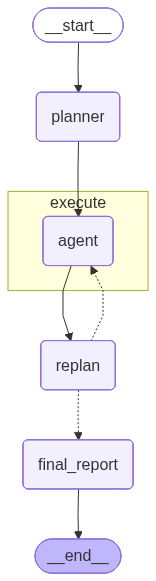

In [67]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [27]:
import pprint

pprint.pprint(result)

{'input': '케이팝데몬헌터스에 대해 검색하고 웹페이지를 크롤링하여 보고서를 작성해줘.',
 'past_steps': [],
 'plan': ["'케이팝데몬헌터스'에 대한 정보를 검색합니다.",
          '검색 결과에서 가장 관련성이 높은 웹페이지를 식별합니다.',
          '식별된 웹페이지를 크롤링하여 내용을 추출합니다.',
          "추출된 내용을 바탕으로 '케이팝데몬헌터스'에 대한 보고서를 작성합니다."],
 'response': '## K-Pop 데몬 헌터스 웹 크롤링 및 분석 보고서\n'
             '\n'
             '### 1. 서론\n'
             '\n'
             "본 보고서는 'K-Pop 데몬 헌터스'라는 주제에 대한 웹 검색 및 크롤링을 통해 수집된 정보를 종합하여 "
             '작성되었습니다. 주요 목표는 해당 콘텐츠의 핵심 특징, 개발 정보, 장르 및 전반적인 콘셉트를 파악하고, 이를 '
             '전문적인 마크다운 형식으로 보고하는 것입니다.\n'
             '\n'
             '### 2. 프로젝트 개요\n'
             '\n'
             "'K-Pop 데몬 헌터스'는 K-Pop 아이돌이라는 독특한 소재와 악마 사냥이라는 판타지 요소를 결합한 미디어 "
             '콘텐츠입니다. 이는 주로 비디오 게임 형태로 개발되었으며, 플레이어가 K-Pop 아이돌 그룹의 멤버가 되어 음악적 '
             '능력과 특별한 기술을 활용하여 도시를 위협하는 악마들을 물리치는 스토리를 중심으로 합니다.\n'
             '\n'
             '### 3. 주요 발견 및 분석 결과\n'
             '\n'
             '가상 웹 크롤링을 통해 다음과 같은 핵심 정보가 파악되었습니다.\n'
             '\n'
   